In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [46]:
df_men =pd.read_csv(r"/home/ducvu0904/Documents/Lab/Conversion vs revenue benchmarking/dataset/Hillstrom/Women/Hillstrom-Women.csv")


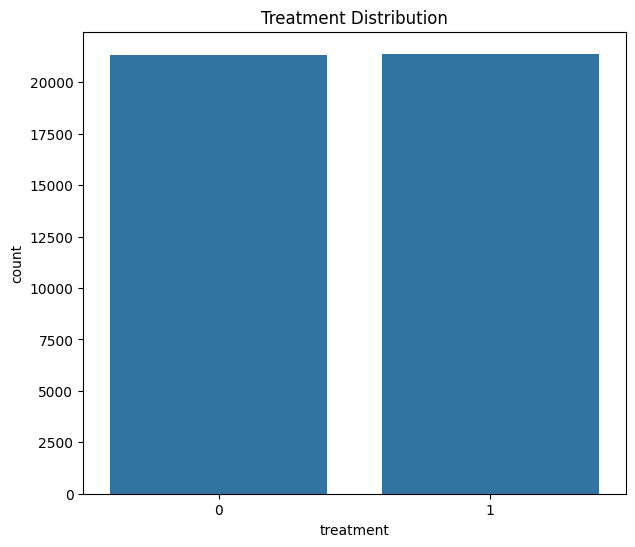

In [47]:
plt.figure(figsize=(7,6))
sns.countplot(data = df_men, x = 'treatment')
plt.title("Treatment Distribution")
plt.show()

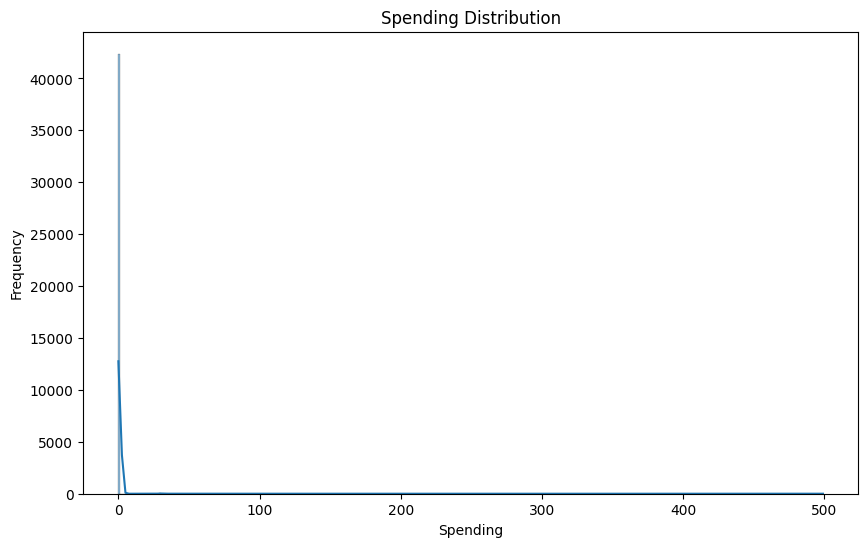

In [48]:
plt.figure(figsize=(10,6))
sns.histplot(data= df_men, x="spend", kde=True)
plt.title('Spending Distribution')
plt.xlabel('Spending')
plt.ylabel('Frequency')
plt.show()

spend
0.00      42382
29.99        66
30.70         1
31.03         1
32.07         1
          ...  
414.08        1
444.33        1
444.92        1
462.78        1
499.00        6
Name: count, Length: 241, dtype: int64
Percentage of customers who didn't spend: 99.27154334434216%


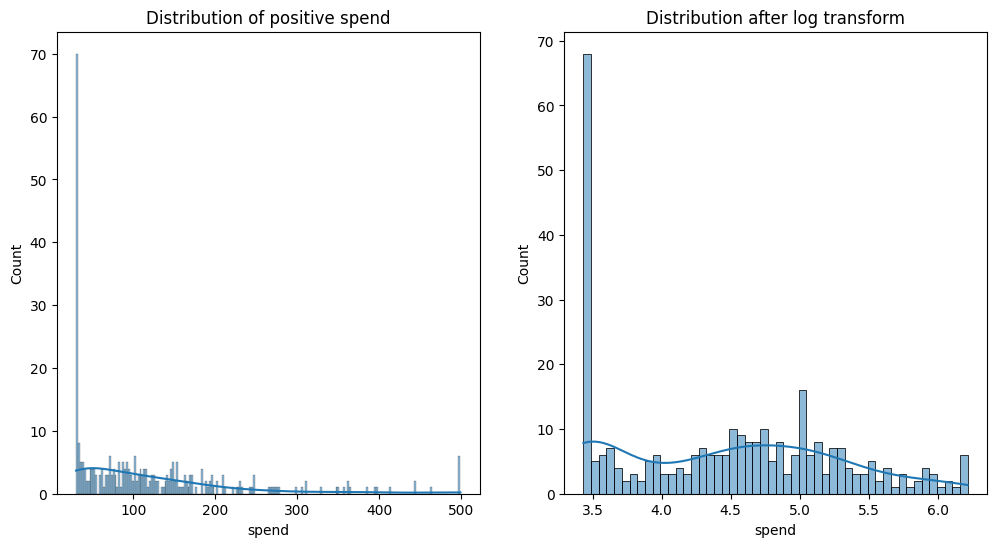

In [49]:
#EDA Spend
spend_count = df_men["spend"].value_counts()
print(spend_count.sort_index())

zero_fraction  = (df_men["spend"]==0).mean()
print (f"Percentage of customers who didn't spend: {zero_fraction*100}%")

positive_spend = df_men[df_men["spend"]>0]["spend"]

fig, axes = plt.subplots(1,2, figsize=(12,6))

sns.histplot(data= positive_spend, bins = 200, ax=axes[0], kde = True)
axes[0].set_title("Distribution of positive spend")

sns.histplot(data= np.log1p(positive_spend), bins = 50, ax=axes[1], kde=True)
axes[1].set_title("Distribution after log transform")
plt.show()

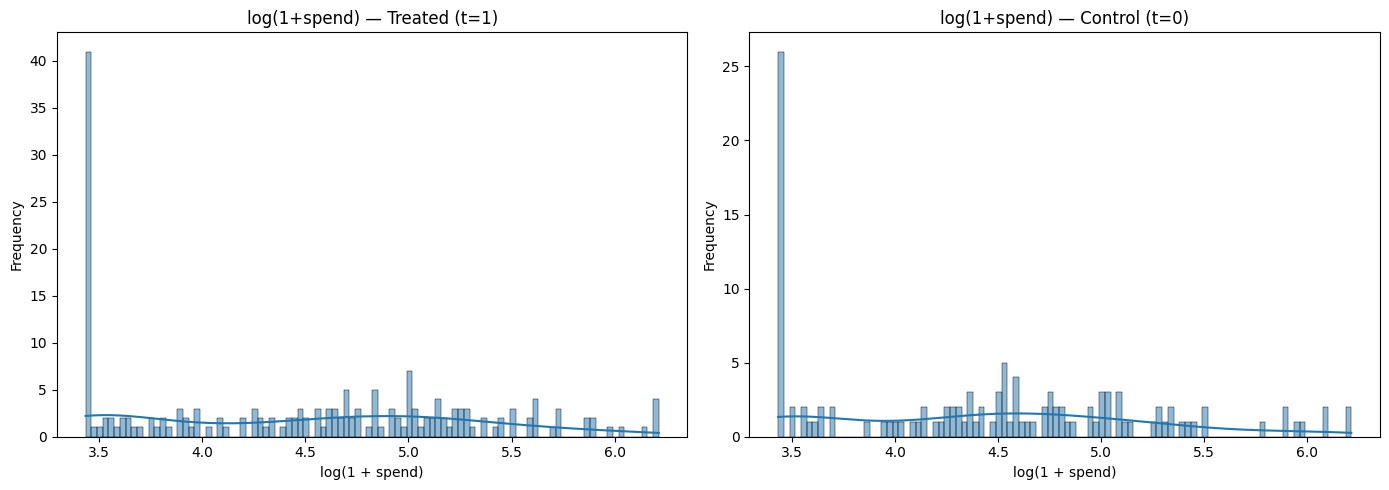

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, group, label in zip(axes, [1, 0], ["Treated (t=1)", "Control (t=0)"]):
    pos = df_men.loc[(df_men["treatment"] == group) & (df_men["spend"] > 0), "spend"]
    sns.histplot(np.log1p(pos), bins=100, kde=True, ax=ax)
    ax.set_title(f"log(1+spend) — {label}")
    ax.set_xlabel("log(1 + spend)")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

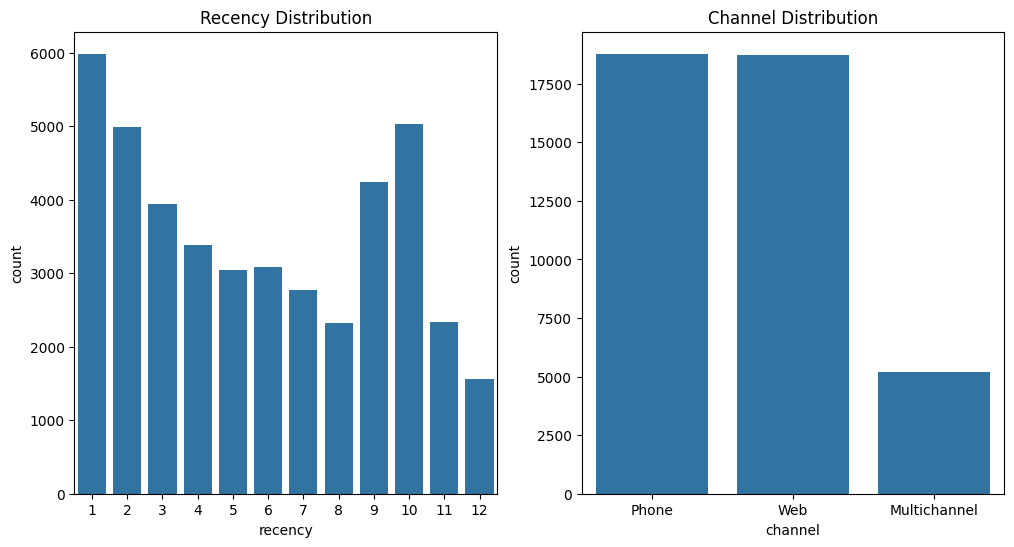

In [51]:
fig, axes = plt.subplots(1,2, figsize=(12,6))
sns.countplot(data = df_men, x = 'recency', ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.countplot(data = df_men, x = "channel", ax=axes[1])
axes[1].set_title("Channel Distribution")

plt.show()

In [52]:
# ═══════════════════════════════════════════════════════════════════════════
# ATE & KEY STATISTICS — Hillstrom Men
# ═══════════════════════════════════════════════════════════════════════════

t = df_men["treatment"].values
y = df_men["spend"].values

# ── 1. ATE (Average Treatment Effect) ────────────────────────────────────
ate_spend = y[t == 1].mean() - y[t == 0].mean()
print("=" * 60)
print("ATE (Average Treatment Effect)")
print("=" * 60)
print(f"  Avg spend (treated):  {y[t==1].mean():.4f}")
print(f"  Avg spend (control):  {y[t==0].mean():.4f}")
print(f"  ATE (spend):          {ate_spend:.4f}")
print(f"  ATE > 0 → email campaign {'INCREASES' if ate_spend > 0 else 'DECREASES'} spending")

# ── 2. Conversion-based ATE ──────────────────────────────────────────────
conv = df_men["conversion"].values
ate_conv = conv[t == 1].mean() - conv[t == 0].mean()
print(f"\n  Conversion rate (treated): {conv[t==1].mean():.4%}")
print(f"  Conversion rate (control): {conv[t==0].mean():.4%}")
print(f"  ATE (conversion):          {ate_conv:.4%}")

# ── 3. Visit-based ATE ───────────────────────────────────────────────────
visit = df_men["visit"].values
ate_visit = visit[t == 1].mean() - visit[t == 0].mean()
print(f"\n  Visit rate (treated): {visit[t==1].mean():.4%}")
print(f"  Visit rate (control): {visit[t==0].mean():.4%}")
print(f"  ATE (visit):          {ate_visit:.4%}")

# ── 4. Dataset overview ──────────────────────────────────────────────────
print(f"\n{'='*60}")
print("DATASET OVERVIEW")
print(f"{'='*60}")
print(f"  Total samples:      {len(df_men)}")
print(f"  Treated:            {(t==1).sum()} ({(t==1).mean():.1%})")
print(f"  Control:            {(t==0).sum()} ({(t==0).mean():.1%})")
print(f"  Zero spend:         {(y==0).sum()} ({(y==0).mean():.1%})")
print(f"  Positive spend:     {(y>0).sum()} ({(y>0).mean():.1%})")

# ── 5. Spend distribution by group ───────────────────────────────────────
print(f"\n{'='*60}")
print("SPEND BY GROUP")
print(f"{'='*60}")
for group, label in [(1, "Treated"), (0, "Control")]:
    yg = y[t == group]
    pos = yg[yg > 0]
    print(f"\n  {label}:")
    print(f"    Mean spend (all):      {yg.mean():.4f}")
    print(f"    Median spend (all):    {np.median(yg):.4f}")
    print(f"    Std spend (all):       {yg.std():.4f}")
    print(f"    Positive rate:         {(yg>0).mean():.4%}")
    if len(pos) > 0:
        print(f"    Mean spend (if > 0):   {pos.mean():.4f}")
        print(f"    Median spend (if > 0): {np.median(pos):.4f}")
    print(f"    Max spend:             {yg.max():.4f}")

# ── 6. Statistical significance ──────────────────────────────────────────
from scipy.stats import ttest_ind, mannwhitneyu
print(f"\n{'='*60}")
print("STATISTICAL SIGNIFICANCE")
print(f"{'='*60}")
t_stat, p_val = ttest_ind(y[t==1], y[t==0])
print(f"  t-test (spend):      t={t_stat:.4f}, p={p_val:.4f} {'✅ Sig' if p_val < 0.05 else '❌ Not sig'}")

u_stat, p_val_u = mannwhitneyu(y[t==1], y[t==0], alternative='two-sided')
print(f"  Mann-Whitney (spend): U={u_stat:.0f}, p={p_val_u:.4f} {'✅ Sig' if p_val_u < 0.05 else '❌ Not sig'}")

t_stat_c, p_val_c = ttest_ind(conv[t==1], conv[t==0])
print(f"  t-test (conversion): t={t_stat_c:.4f}, p={p_val_c:.4f} {'✅ Sig' if p_val_c < 0.05 else '❌ Not sig'}")

ATE (Average Treatment Effect)
  Avg spend (treated):  1.0772
  Avg spend (control):  0.6528
  ATE (spend):          0.4244
  ATE > 0 → email campaign INCREASES spending

  Conversion rate (treated): 0.8837%
  Conversion rate (control): 0.5726%
  ATE (conversion):          0.3111%

  Visit rate (treated): 15.1400%
  Visit rate (control): 10.6167%
  ATE (visit):          4.5233%

DATASET OVERVIEW
  Total samples:      42693
  Treated:            21387 (50.1%)
  Control:            21306 (49.9%)
  Zero spend:         42382 (99.3%)
  Positive spend:     311 (0.7%)

SPEND BY GROUP

  Treated:
    Mean spend (all):      1.0772
    Median spend (all):    0.0000
    Std spend (all):       15.1158
    Positive rate:         0.8837%
    Mean spend (if > 0):   121.8948
    Median spend (if > 0): 94.7100
    Max spend:             499.0000

  Control:
    Mean spend (all):      0.6528
    Median spend (all):    0.0000
    Std spend (all):       11.5879
    Positive rate:         0.5726%
    Mean 

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Embedding-ready preprocess:
# - Numeric features: StandardScaler
# - Categorical features: integer IDs (0 reserved for unknown)
categorical_cols = ["history_segment", "zip_code", "channel"]
numeric_cols = ["recency", "history", "mens", "womens", "newbie"]

# split x, treatment and labels
y_men = df_men["spend"]
t_men = df_men["treatment"]
conv_men = df_men["conversion"]
visit_men = df_men["visit"]
x_men = df_men.drop(columns=["spend", "treatment", "conversion", "visit"])

# stratify by treatment x purchase(y > 0)
stratify_combined = t_men.astype(str) + "_" + (y_men > 0).astype(int).astype(str)

# train/test split
(
    x_men_train,
    x_men_test,
    t_men_train,
    t_men_test,
    y_men_train,
    y_men_test,
    conv_men_train,
    conv_men_test,
    visit_men_train,
    visit_men_test,
) = train_test_split(
    x_men,
    t_men.values,
    y_men.values,
    conv_men.values,
    visit_men.values,
    test_size=0.3,
    random_state=42,
    stratify=stratify_combined,
)

# stratify for val split
stratify_var_train = pd.Series(t_men_train).astype(str) + "_" + (pd.Series(y_men_train) > 0).astype(int).astype(str)

# split train into train/val
(
    x_men_train,
    x_men_val,
    t_men_train,
    t_men_val,
    y_men_train,
    y_men_val,
    conv_men_train,
    conv_men_val,
    visit_men_train,
    visit_men_val,
) = train_test_split(
    x_men_train,
    t_men_train,
    y_men_train,
    conv_men_train,
    visit_men_train,
    test_size=(1 / 7),
    random_state=42,
    stratify=stratify_var_train,
)

# 1) Numeric scaling
scaler = StandardScaler()
x_train_num = pd.DataFrame(
    scaler.fit_transform(x_men_train[numeric_cols]),
    columns=numeric_cols,
    index=x_men_train.index,
)
x_val_num = pd.DataFrame(
    scaler.transform(x_men_val[numeric_cols]),
    columns=numeric_cols,
    index=x_men_val.index,
)
x_test_num = pd.DataFrame(
    scaler.transform(x_men_test[numeric_cols]),
    columns=numeric_cols,
    index=x_men_test.index,
)

# 2) Categorical ID encoding (fit on train only)
def fit_category_mapping(series):
    unique_vals = pd.Series(series.astype(str).unique()).sort_values()
    return {v: i + 1 for i, v in enumerate(unique_vals.tolist())}

category_mappings = {}
category_cardinalities = {}

x_train_cat = pd.DataFrame(index=x_men_train.index)
x_val_cat = pd.DataFrame(index=x_men_val.index)
x_test_cat = pd.DataFrame(index=x_men_test.index)

for col in categorical_cols:
    mapping = fit_category_mapping(x_men_train[col])
    category_mappings[col] = mapping
    category_cardinalities[col] = len(mapping) + 1

    id_col = f"{col}_id"
    x_train_cat[id_col] = x_men_train[col].astype(str).map(mapping).fillna(0).astype(int)
    x_val_cat[id_col] = x_men_val[col].astype(str).map(mapping).fillna(0).astype(int)
    x_test_cat[id_col] = x_men_test[col].astype(str).map(mapping).fillna(0).astype(int)

# 3) Final embedding-ready features
x_men_train = pd.concat([x_train_num, x_train_cat], axis=1)
x_men_val = pd.concat([x_val_num, x_val_cat], axis=1)
x_men_test = pd.concat([x_test_num, x_test_cat], axis=1)

feature_cols = x_men_train.columns.tolist()
cat_id_cols = [f"{c}_id" for c in categorical_cols]

print("Completed embedding-ready preprocess (numeric + categorical IDs).")
print(f"Train: {x_men_train.shape}, Val: {x_men_val.shape}, Test: {x_men_test.shape}")
print(f"Numeric cols: {numeric_cols}")
print(f"Categorical ID cols: {cat_id_cols}")
print(f"Category cardinalities (for embeddings): {category_cardinalities}")
print(f"Treatment distribution - Train: {np.mean(t_men_train):.2%}, Val: {np.mean(t_men_val):.2%}, Test: {np.mean(t_men_test):.2%}")
print(f"Purchase rate - Train: {np.mean(y_men_train > 0):.2%}, Val: {np.mean(y_men_val > 0):.2%}, Test: {np.mean(y_men_test > 0):.2%}")
print(f"Spend mean - Train: {np.mean(y_men_train):.2f}, Val: {np.mean(y_men_val):.2f}, Test: {np.mean(y_men_test):.2f}")
print(f"Conversion rate - Train: {np.mean(conv_men_train):.2%}, Val: {np.mean(conv_men_val):.2%}, Test: {np.mean(conv_men_test):.2%}")
print(f"Visit rate - Train: {np.mean(visit_men_train):.2%}, Val: {np.mean(visit_men_val):.2%}, Test: {np.mean(visit_men_test):.2%}")

✅ Train/Val/Test split with stratification by TREATMENT x PURCHASE
Train: (25615, 11), Val: (4270, 11), Test: (12808, 11)
Treatment distribution - Train: 50.10%, Val: 50.09%, Test: 50.09%
Purchase rate - Train: 0.73%, Val: 0.73%, Test: 0.73%
Spend mean - Train: 0.85, Val: 0.68, Test: 0.96
Conversion rate - Train: 0.73%, Val: 0.73%, Test: 0.73%
Visit rate - Train: 12.73%, Val: 12.62%, Test: 13.28%


In [ ]:
import os
import json

# Build final DataFrames for CSV export
df_train = pd.DataFrame(x_men_train, columns=feature_cols)
df_train["treatment"] = t_men_train
df_train["spend"] = y_men_train
df_train["conversion"] = conv_men_train
df_train["visit"] = visit_men_train

df_val = pd.DataFrame(x_men_val, columns=feature_cols)
df_val["treatment"] = t_men_val
df_val["spend"] = y_men_val
df_val["conversion"] = conv_men_val
df_val["visit"] = visit_men_val

df_test = pd.DataFrame(x_men_test, columns=feature_cols)
df_test["treatment"] = t_men_test
df_test["spend"] = y_men_test
df_test["conversion"] = conv_men_test
df_test["visit"] = visit_men_test

for _df in [df_train, df_val, df_test]:
    unnamed_cols = [c for c in _df.columns if str(c).lower().startswith("unnamed")]
    if unnamed_cols:
        _df.drop(columns=unnamed_cols, inplace=True)

# Export into current workspace
save_dir = r"/home/ducvu0904/Documents/Lab/RERUM/dataset/Hillstrom/Women"

train_path = os.path.join(save_dir, "train_women.csv")
val_path = os.path.join(save_dir, "val_women.csv")
test_path = os.path.join(save_dir, "test_women.csv")
meta_path = os.path.join(save_dir, "feature_meta_women.json")

df_train.to_csv(train_path, index=False)
df_val.to_csv(val_path, index=False)
df_test.to_csv(test_path, index=False)

feature_meta = {
    "numeric_cols": numeric_cols,
    "categorical_id_cols": cat_id_cols,
    "categorical_cardinalities": category_cardinalities,
    "embedding_dim_recommended": 10,
}

with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(feature_meta, f, indent=2, ensure_ascii=True)

print(f"Saved train data: {train_path}")
print(f"Saved val data: {val_path}")
print(f"Saved test data: {test_path}")
print(f"Saved feature meta: {meta_path}")
print(f"Columns - Train: {df_train.shape[1]}, Val: {df_val.shape[1]}, Test: {df_test.shape[1]}")
print("Included labels: spend, conversion, visit")

✅ Đã lưu tập Train Data tại: /home/ducvu0904/Documents/Lab/Conversion vs revenue benchmarking/dataset/Hillstrom/Women/train_women.csv
✅ Đã lưu tập Val Data tại: /home/ducvu0904/Documents/Lab/Conversion vs revenue benchmarking/dataset/Hillstrom/Women/val_women.csv
✅ Đã lưu tập Test Data tại: /home/ducvu0904/Documents/Lab/Conversion vs revenue benchmarking/dataset/Hillstrom/Women/test_women.csv
Columns - Train: 14, Val: 14, Test: 14
Included labels: spend, conversion, visit


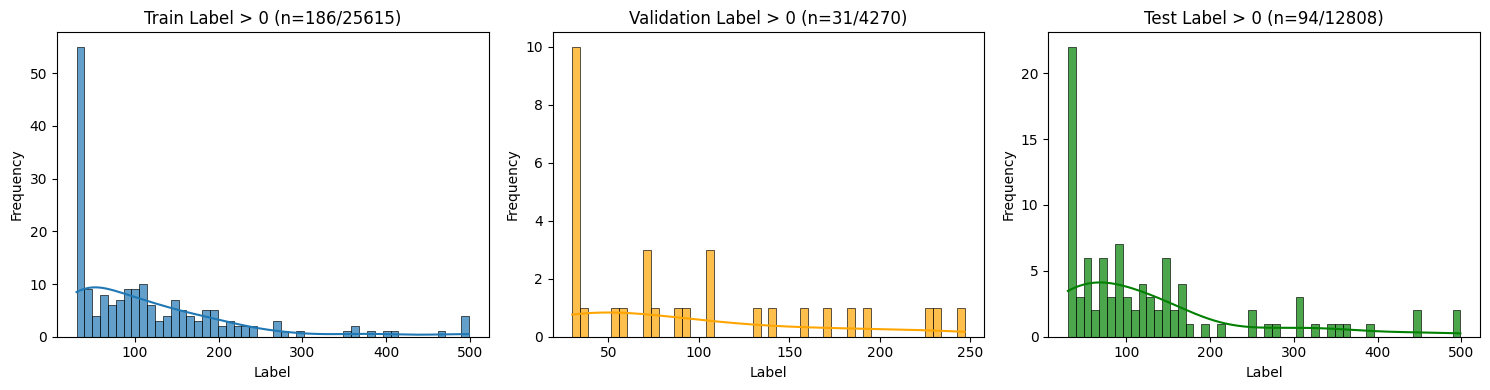

Train (>0) - Mean: 116.9396, Std: 103.0279, Min: 29.9900, Max: 499.0000
Val   (>0) - Mean: 93.8574, Std: 67.3792, Min: 29.9900, Max: 246.9000
Test  (>0) - Mean: 130.7032, Std: 115.0380, Min: 29.9900, Max: 499.0000


In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter only values > 0
y_train_pos = y_men_train[y_men_train > 0]
y_val_pos = y_men_val[y_men_val > 0]
y_test_pos = y_men_test[y_men_test > 0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Train
sns.histplot(y_train_pos, bins=50, kde=True, ax=axes[0], alpha=0.7, edgecolor='black')
axes[0].set_title(f'Train Label > 0 (n={len(y_train_pos)}/{len(y_men_train)})')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Frequency')

# Validation
sns.histplot(y_val_pos, bins=50, kde=True, ax=axes[1], alpha=0.7, color='orange', edgecolor='black')
axes[1].set_title(f'Validation Label > 0 (n={len(y_val_pos)}/{len(y_men_val)})')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Frequency')

# Test
sns.histplot(y_test_pos, bins=50, kde=True, ax=axes[2], alpha=0.7, color='green', edgecolor='black')
axes[2].set_title(f'Test Label > 0 (n={len(y_test_pos)}/{len(y_men_test)})')
axes[2].set_xlabel('Label')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Train (>0) - Mean: {y_train_pos.mean():.4f}, Std: {y_train_pos.std():.4f}, Min: {y_train_pos.min():.4f}, Max: {y_train_pos.max():.4f}")
print(f"Val   (>0) - Mean: {y_val_pos.mean():.4f}, Std: {y_val_pos.std():.4f}, Min: {y_val_pos.min():.4f}, Max: {y_val_pos.max():.4f}")
print(f"Test  (>0) - Mean: {y_test_pos.mean():.4f}, Std: {y_test_pos.std():.4f}, Min: {y_test_pos.min():.4f}, Max: {y_test_pos.max():.4f}")

In [56]:
def compute_ate(y, t):
    y = np.asarray(y).reshape(-1)
    t = np.asarray(t).reshape(-1)
    treated = y[t == 1]
    control = y[t == 0]
    return treated.mean() - control.mean()

ate_train = compute_ate(y_men_train, t_men_train)
ate_val = compute_ate(y_men_val, t_men_val)
ate_test = compute_ate(y_men_test, t_men_test)

print(f"ATE (Train): {ate_train:.6f}")
print(f"ATE (Val):   {ate_val:.6f}")
print(f"ATE (Test):  {ate_test:.6f}")

ATE (Train): 0.406813
ATE (Val):   0.236089
ATE (Test):  0.522397


In [57]:
conversion_rates = {
    "Train": np.mean(conv_men_train),
    "Validation": np.mean(conv_men_val),
    "Test": np.mean(conv_men_test),
}

for set_name, rate in conversion_rates.items():
    if set_name == "Train":
        conv_data = conv_men_train
    elif set_name == "Validation":
        conv_data = conv_men_val
    else:
        conv_data = conv_men_test
        
    print(f"{set_name} conversion rate: {rate:.4%} ({conv_data.sum()}/{len(conv_data)})")

Train conversion rate: 0.7261% (186/25615)
Validation conversion rate: 0.7260% (31/4270)
Test conversion rate: 0.7339% (94/12808)
